# Model Distillation & Quantization

The objective of this part is to reduce the computational requirements of our best-performing sarcasm classifier so that it can be deployed cheaply and at scale, and to measure rigorously what that compression costs us in predictive quality. Throughout Parts 1-3 we established a clear ladder of performance: a stratified-random baseline at macro F1 = 0.5108, rule-based VADER classifiers that could not beat it (best macro F1 = 0.4461), and finally a family of DistilBERT models. The strongest of these, a fully fine-tuned (unfrozen) DistilBERT trained on the whole training set, reached **macro F1 = 0.733 and accuracy = 0.744** (Part 3), our best result overall and the model we now take as the starting point for compression.

### a) Model Distillation / Quantization

#### Setup, configuration and data

We maintain the same tokenisation our group has used.

In [1]:
import os, time, copy, tempfile, random, warnings, gc
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DistilBertConfig, DistilBertForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding, EarlyStoppingCallback, set_seed
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.tokenize.treebank import TreebankWordDetokenizer
import psutil
from codecarbon import EmissionsTracker

warnings.filterwarnings("ignore")

def lock_seeds(seed):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    set_seed(seed)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

CONFIG = {
    "seed": 7994,
    "max_len": 512,  # pad to the DistilBERT maximum (512 tokens), as in Parts 2-3
    "model_name": "distilbert-base-uncased",
    "teacher_dir": "../models/teacher_distilbert",
    "student_layers": 3,
    "student_epochs": 2,
    "student_lr": 5e-5,
    "kd_temperature": 2.0,
    "kd_alpha": 0.5,
    "batch_size": 8,
    "eval_batch": 64,
}
lock_seeds(CONFIG["seed"])
print(f"Device: {DEVICE} | torch {torch.__version__}")

c:\Users\qwert\Documents\AdvancedNLP\Final_Project\sarcasm_text_classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda | torch 2.12.1+cu130


In [2]:
df = pd.read_csv("../data/cleaned_sarcasm_dataset.csv")
label_map = {"Non-Sarcastic": 0, "Sarcastic": 1}

train_df = df[df["split"] == "train"].copy()
test_df  = df[df["split"] == "test"].copy()
train_df["labels"] = train_df["label"].astype(str).map(label_map)
test_df["labels"]  = test_df["label"].astype(str).map(label_map)

print(f"Train: {len(train_df)}   Test: {len(test_df)}")
print("Test class balance:")
print(test_df["labels"].value_counts().rename({0: 'Non-Sarcastic', 1: 'Sarcastic'}))

Train: 2936   Test: 734
Test class balance:
labels
Sarcastic        462
Non-Sarcastic    272
Name: count, dtype: int64


In [3]:
tokenizer = AutoTokenizer.from_pretrained(CONFIG["model_name"])

class SarcasmDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.enc = tokenizer(list(texts), padding="max_length", truncation=True, max_length=max_len)
        self.labels = list(labels)
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, i):
        item = {}
        for k in self.enc:
            item[k] = self.enc[k][i]
        item["labels"] = int(self.labels[i])
        return item

train_ds = SarcasmDataset(train_df["Sentence"], train_df["labels"], tokenizer, CONFIG["max_len"])
test_ds  = SarcasmDataset(test_df["Sentence"],  test_df["labels"],  tokenizer, CONFIG["max_len"])
collator = DataCollatorWithPadding(tokenizer)
test_texts  = test_df["Sentence"].tolist()
test_labels = np.array(test_df["labels"].tolist())

#### Shared evaluation utilities

- **Latency** time for one forward pass on a single sentence, processed one at a time.
- **Throughput** how many sentences are processed per second in batched inference over the whole holdout.
- **CO2** energy of the inference pass over the 734-sentence holdout, i.e. the cost of running the model, not of training/building it.
- **Size** Size on disk. 
- Note: We don't measure RAM since its performance is bounded by Python/PyTorch process rather than the model.
- Note: our measure_efficiency function reports various metrics (latency, throughput, and energy), which are measured with the model running on CPU, since PyTorch's dynamic int8 quantization is CPU-only. This would mean that the quantized teacher and the stacked student run on CPU only. However, training and the fp32 accuracy evaluation still use the GPU, since the training device has no bearing on the deployment metrics; only the efficiency comparison is fixed to CPU.

In [ ]:
def disk_size_mb(model):
    fd, path = tempfile.mkstemp(suffix=".pt")
    os.close(fd)
    try:
        torch.save(model.state_dict(), path)
        return os.path.getsize(path) / 1e6
    finally:
        if os.path.exists(path):
            os.remove(path)

def n_params(model):
    total = 0
    for p in model.parameters():
        total += p.numel()
    return total

@torch.no_grad()
def predict_logits(model, dataset, device, batch_size=64):
    model.eval().to(device)
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=collator)
    out = []
    for batch in loader:
        inp = {}
        for k, v in batch.items():
            if k in ("input_ids", "attention_mask"):
                inp[k] = v.to(device)
        out.append(model(**inp).logits.float().cpu())
    return torch.cat(out).numpy()

def evaluate(model, dataset, labels, device, name=""):
    logits = predict_logits(model, dataset, device)
    preds = logits.argmax(-1)
    probs = torch.softmax(torch.tensor(logits), -1).numpy()
    per_class = f1_score(labels, preds, average=None, zero_division=0)
    res = {
        "name": name,
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "macro_precision": precision_score(labels, preds, average="macro", zero_division=0),
        "macro_recall": recall_score(labels, preds, average="macro", zero_division=0),
        "f1_nonsarc": per_class[0],
        "f1_sarc":    per_class[1],
    }
    return res, preds, probs

@torch.no_grad()
def benchmark_latency(model, texts, tokenizer, device, max_len, n_warmup=5, n_runs=120):
    model.eval().to(device)
    sample = texts[:n_runs] if len(texts) >= n_runs else texts
    def run_one(t):
        enc = tokenizer(t, padding="max_length", truncation=True, max_length=max_len, return_tensors="pt")
        moved = {}
        for k, v in enc.items():
            moved[k] = v.to(device)
        model(**moved)
    for t in sample[:n_warmup]:
        run_one(t)
    times = []
    for t in sample:
        s = time.perf_counter(); run_one(t); times.append((time.perf_counter() - s) * 1000)
    return float(np.mean(times)), float(np.std(times))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.asarray(logits).argmax(-1)
    return {"accuracy": accuracy_score(labels, preds),
            "macro_f1": f1_score(labels, preds, average="macro", zero_division=0)}

@torch.no_grad()
def measure_efficiency(model, dataset, device, batch_size=64):
    model.eval().to(device)
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=collator)
    proc = psutil.Process(os.getpid())
    gc.collect()
    ram_base = proc.memory_info().rss / 1e6 if proc else float("nan")
    ram_peak = ram_base
    tracker = None
    try:
        tracker = EmissionsTracker(project_name="part4_sarcasm", measure_power_secs=1, save_to_file=False, allow_multiple_runs=True)
        tracker.start()
    except Exception:
        tracker = None
    n = 0
    t0 = time.perf_counter()
    for batch in loader:
        inp = {}
        for k, v in batch.items():
            if k in ("input_ids", "attention_mask"):
                inp[k] = v.to(device)
        model(**inp)
        n += inp["input_ids"].shape[0]
        if proc:
            ram_peak = max(ram_peak, proc.memory_info().rss / 1e6)
    elapsed = time.perf_counter() - t0
    carbon_kg = float("nan")
    if tracker is not None:
        try:
            carbon_kg = float(tracker.stop())
        except Exception:
            carbon_kg = float("nan")
    return {
        "throughput_sps": (n / elapsed) if elapsed > 0 else float("nan"),
        "ram_peak_mb": ram_peak,
        "ram_used_mb": (ram_peak - ram_base) if proc else float("nan"),
        "carbon_kg": carbon_kg,
        "n_eval": n,
    }


def report_metrics(res, ref=None):
    bar = "=" * 70
    print(bar); print(res["name"]); print(bar)
    cmp = ref is not None and res is not ref
    s = f"  SIZE         params = {res['params']/1e6:5.1f} M     on-disk = {res['size_mb']:6.1f} MB"
    if cmp: s += f"   ({ref['size_mb']/res['size_mb']:.2f}x smaller than teacher)"
    print(s)
    thr = res.get("throughput_sps", float("nan"))
    s = f"  SPEED        latency = {res['latency_ms']:5.1f} ms/sent (batch=1)   throughput = {thr:6.1f} sent/s (batched)"
    if cmp: s += f"   ({ref['latency_ms']/res['latency_ms']:.2f}x faster than teacher)"
    print(s)
    print(f"  PERFORMANCE  accuracy = {res['accuracy']:.4f}   macro-F1 = {res['macro_f1']:.4f}"
          f"   macro-P = {res['macro_precision']:.4f}   macro-R = {res['macro_recall']:.4f}")
    s = f"               per-class F1:  Non-Sarc = {res['f1_nonsarc']:.4f}   Sarc = {res['f1_sarc']:.4f}"
    if cmp: s += f"   (macro-F1 delta = {res['macro_f1']-ref['macro_f1']:+.4f})"
    print(s)
    if "fidelity_vs_teacher" in res:
        print(f"               fidelity to teacher (label agreement) = {res['fidelity_vs_teacher']:.3f}")
    c = res.get("carbon_kg", float("nan"))
    cstr = f"{c*1e3:.4f} g CO2eq / inference pass" if c == c else "n/a (codecarbon unavailable)"
    print(f"  CO2 carbon = {cstr}")
    print()


#### Our best model

In [5]:
teacher = AutoModelForSequenceClassification.from_pretrained("../results_unfrozen_100/checkpoint-734")

results = {}

teacher_res, teacher_preds, teacher_probs = evaluate(teacher, test_ds, test_labels, DEVICE, "Teacher (DistilBERT fp32)")
teacher_res["params"]   = n_params(teacher)
teacher_res["size_mb"]  = disk_size_mb(teacher)
teacher_res["latency_ms"], teacher_res["latency_std"] = benchmark_latency(teacher, test_texts, tokenizer, torch.device("cpu"), CONFIG["max_len"])
teacher_res.update(measure_efficiency(teacher, test_ds, torch.device("cpu")))
results["teacher"] = teacher_res

print(classification_report(test_labels, teacher_preds, target_names=["Non-Sarcastic", "Sarcastic"], zero_division=0))
report_metrics(teacher_res)

Loading weights: 100%|██████████| 104/104 [00:00<00:00, 9854.68it/s]
[codecarbon WARNING @ 19:19:00] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:19:02] [setup] RAM Tracking...
[codecarbon INFO @ 19:19:02] [setup] CPU Tracking...
[codecarbon WARNING @ 19:19:04] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 19:19:04] CPU Model on constant consumption mode: AMD Ryzen 9 8940HX with Radeon Graphics
[codecarbon WARNING @ 19:19:04] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 19:19:04] [setup] GPU Tracking...
[codecarbon INFO @ 19:19:04] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 19:19:04] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml

               precision    recall  f1-score   support

Non-Sarcastic       0.62      0.76      0.68       272
    Sarcastic       0.84      0.72      0.78       462

     accuracy                           0.74       734
    macro avg       0.73      0.74      0.73       734
 weighted avg       0.76      0.74      0.74       734

Teacher (DistilBERT fp32)
  SIZE         params =  67.0 M     on-disk =  267.9 MB
  SPEED        latency =  80.4 ms/sent (batch=1)   throughput =   13.4 sent/s (batched)
  PERFORMANCE  accuracy = 0.7371   macro-F1 = 0.7292   macro-P = 0.7280   macro-R = 0.7427
               per-class F1:  Non-Sarc = 0.6831   Sarc = 0.7753
  CO2 carbon = 0.1162 g CO2eq / inference pass



Our best model has the following performance metrics:
- **Size:** 67.0 M parameters, 267.9 MB on disk. 
- **Speed:** ~80 ms/sentence latency, ~13 sentences/s. 
- **Performance:** 
  - accuracy 0.737
  - macro-F1 0.729
  - macro-precision 0.728
  - macro-recall 0.743
  - Per-class F1: 0.683 (Non-Sarcastic) and 0.775 (Sarcastic)
- **CO2:** ~0.116 g CO2eq per 734-sentence evaluation pass.

#### Technique 1: Quantization (dynamic, INT8)

Quantization is the cheaper of our two techniques because it requires no retraining and no labelled data. A fine-tuned transformer spends almost all of its weights and arithmetic in Linear layers. Post-training dynamic quantization stores those weight matrices as 8-bit integers and converts the activations to int8 while the model runs. We choose the dynamic variant over the two alternatives deliberately: static post-training quantization would require a calibration step (running sample data through the model to measure the activation ranges and fix them in advance) and Quantization-Aware Training quantization-aware training would mean fine-tuning the whole model again while imitating int8 as it trains.

In [6]:
teacher_cpu = copy.deepcopy(teacher).to("cpu").eval()
quantized = torch.quantization.quantize_dynamic(teacher_cpu, {torch.nn.Linear}, dtype=torch.qint8)

quant_res, quant_preds, quant_probs = evaluate(quantized, test_ds, test_labels, torch.device("cpu"), "Quantized (DistilBERT int8)")
quant_res["params"]  = n_params(teacher)
quant_res["size_mb"] = disk_size_mb(quantized)
quant_res["latency_ms"], quant_res["latency_std"] = benchmark_latency(quantized, test_texts, tokenizer, torch.device("cpu"), CONFIG["max_len"])
quant_res.update(measure_efficiency(quantized, test_ds, torch.device("cpu")))
results["quantized"] = quant_res

print("QUANTIZED (int8, dynamic)")
print(classification_report(test_labels, quant_preds, target_names=["Non-Sarcastic", "Sarcastic"], zero_division=0))
report_metrics(quant_res, ref=teacher_res)

[codecarbon WARNING @ 19:21:02] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:21:04] [setup] RAM Tracking...
[codecarbon INFO @ 19:21:04] [setup] CPU Tracking...
[codecarbon WARNING @ 19:21:04] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 19:21:04] CPU Model on constant consumption mode: AMD Ryzen 9 8940HX with Radeon Graphics
[codecarbon WARNING @ 19:21:04] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 19:21:04] [setup] GPU Tracking...
[codecarbon INFO @ 19:21:04] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 19:21:04] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 19:21:04] >>> Tracker's metadata:
[c

QUANTIZED (int8, dynamic)
               precision    recall  f1-score   support

Non-Sarcastic       0.54      0.84      0.66       272
    Sarcastic       0.86      0.58      0.70       462

     accuracy                           0.68       734
    macro avg       0.70      0.71      0.68       734
 weighted avg       0.74      0.68      0.68       734

Quantized (DistilBERT int8)
  SIZE         params =  67.0 M     on-disk =  138.7 MB   (1.93x smaller than teacher)
  SPEED        latency =  36.5 ms/sent (batch=1)   throughput =   35.0 sent/s (batched)   (2.20x faster than teacher)
  PERFORMANCE  accuracy = 0.6785   macro-F1 = 0.6774   macro-P = 0.7014   macro-R = 0.7113
               per-class F1:  Non-Sarc = 0.6590   Sarc = 0.6959   (macro-F1 delta = -0.0518)
  CO2 carbon = 0.0457 g CO2eq / inference pass



**Size.** Dynamic int8 stores weights in 8 bits instead of 32, so a 4x reduction is possible in theory, but only on the parts it converts. The 267.9 MB teacher is really two pieces: the embedding table (~95 MB, untouched) and the Linear layers (~173 MB). Quantization shrinks only the Linear layers, by the full 4x to ~43 MB, while the fp32 embedding table stays at ~95 MB. The model therefore drops from 267.9 to 138.7 MB (1.93x smaller), not 4x, because the untouched embedding table now dominates.

**Speed.** Int8 Linear kernels cut CPU latency from 80.4 to 36.5 ms/sentence (2.20x faster) and lift throughput from ~13 to ~35 sentences/s.

**Performance.** Quality drops modestly:
- Accuracy from 0.737 to 0.679
- Macro-F1 from 0.729 to 0.677
- Macro-precision from 0.728 to 0.701
- Macro-recall from 0.743 to 0.711
- Per-class F1: Non-Sarcastic (0.659) and Sarcastic (0.696)
  - Both classes lose ground (Non-Sarcastic F1 from 0.683 to 0.659, Sarcastic F1 from 0.775 to 0.696), so int8 rounding costs roughly five macro-F1 points here, a steeper drop than dynamic quantization usually causes.

**CO2.** The faster model is the greener one: from ~0.116 to ~0.046 g CO2eq per eval pass (~2.5x less).

For zero retraining and no labelled data, quantization buys ~1.9x smaller, ~2.2x faster, and ~2.5x greener, at a cost of roughly five macro-F1 points.

#### Technique 2: Knowledge distillation into a smaller student

Quantization keeps the network's shape and only changes how weights are stored; distillation instead trains a genuinely smaller network, so it is the technique that attacks the parameter count and depth directly. The student is trained not on the binary labels alone but to also match the teacher's outputs.

**AI Disclaimer:** We used AI to research how to implement distillation into code. We learned the following:

Knowledge distillation transfers the behaviour of a large "teacher" model into a smaller "student." Alongside the hard 0/1 labels, the student is trained to reproduce the teacher's softened output distribution, the relative confidences across classes that Hinton et al. (2015) term the teacher's "dark knowledge." DistilBERT (Sanh et al., 2019) is itself a distilled version of BERT, so the teacher used here is already a compressed model, and this step compresses it a second time.

The training objective combines two terms. The first is a temperature-scaled Kullback–Leibler divergence that pulls the student's softened logits toward the teacher's; the second is an ordinary cross-entropy against the true labels. A single weight α balances them: values nearer 1 emphasise imitating the teacher, values nearer 0 emphasise fitting the gold labels. The temperature T sets how soft the targets are: a higher T flattens both distributions and exposes more of the between-class structure the student is meant to absorb, and the KL term is scaled by T² so its gradient stays comparable to the cross-entropy. This implementation uses T = 2 and α = 0.5.

The student is not trained from scratch. It is a 3-layer DistilBERT warm-started from the teacher: the embeddings and the classification head are copied directly, and the three transformer blocks are initialised from evenly spaced teacher layers (0, 2, and 5). It therefore inherits part of the teacher's representation before distillation begins, which makes the soft-target training a refinement of an existing model rather than a cold start.

The expected outcome, borne out by the results, is that the shallower student keeps most of the teacher's macro-F1 but gives up the most on the hardest cases: longer sentences and the more context-dependent examples, where recovering the contrast between a literal surface and its intended meaning calls for the deeper self-attention the student has given up.

In [7]:
def pick_layers(n_teacher, n_student):
    positions = np.linspace(0, n_teacher - 1, n_student)
    idxs = []
    for x in positions:
        idxs.append(int(round(x)))
    return idxs

def build_student_from_teacher(teacher, n_layers):
    tcfg = teacher.config
    scfg = DistilBertConfig(
        vocab_size=tcfg.vocab_size,
        max_position_embeddings=tcfg.max_position_embeddings,
        dim=tcfg.dim,
        hidden_dim=tcfg.hidden_dim,
        n_heads=tcfg.n_heads,
        n_layers=n_layers,
        dropout=tcfg.dropout,
        attention_dropout=tcfg.attention_dropout,
        seq_classif_dropout=getattr(tcfg, "seq_classif_dropout", 0.2),
        num_labels=2,
    )
    student = DistilBertForSequenceClassification(scfg)
    student.distilbert.embeddings.load_state_dict(teacher.distilbert.embeddings.state_dict())
    idxs = pick_layers(tcfg.n_layers, n_layers)
    for s_i, t_i in enumerate(idxs):
        student.distilbert.transformer.layer[s_i].load_state_dict(teacher.distilbert.transformer.layer[t_i].state_dict())
    student.pre_classifier.load_state_dict(teacher.pre_classifier.state_dict())
    student.classifier.load_state_dict(teacher.classifier.state_dict())
    print(f"Student initialised from teacher layers {idxs} ({n_params(student)/1e6:.1f}M params vs teacher {n_params(teacher)/1e6:.1f}M)")
    return student

class DistillationTrainer(Trainer):
    def __init__(self, teacher=None, temperature=2.0, alpha=0.5, **kw):
        super().__init__(**kw)
        self.teacher = teacher
        self.T = temperature
        self.alpha = alpha
        self._ready = False
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs["labels"]
        student_out = model(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"])
        z_s = student_out.logits
        if not self._ready:
            self.teacher.to(z_s.device).eval(); self._ready = True
        with torch.no_grad():
            z_t = self.teacher(input_ids=inputs["input_ids"], attention_mask=inputs["attention_mask"]).logits
        T = self.T
        kd = F.kl_div(F.log_softmax(z_s / T, dim=-1), F.softmax(z_t / T, dim=-1), reduction="batchmean") * (T * T)
        ce = F.cross_entropy(z_s, labels)
        loss = self.alpha * kd + (1 - self.alpha) * ce
        if return_outputs:
            return (loss, student_out)
        else:
            return loss

In [8]:
lock_seeds(CONFIG["seed"])
student = build_student_from_teacher(teacher, CONFIG["student_layers"])

student_args = TrainingArguments(
    output_dir="../results_part4_student",
    num_train_epochs=CONFIG["student_epochs"],
    learning_rate=CONFIG["student_lr"],
    per_device_train_batch_size=CONFIG["batch_size"],
    per_device_eval_batch_size=CONFIG["eval_batch"],
    eval_strategy="epoch", 
    save_strategy="epoch",
    load_best_model_at_end=True, 
    metric_for_best_model="macro_f1", 
    greater_is_better=True,
    seed=CONFIG["seed"], 
    logging_steps=50, 
    report_to="none",
)
distiller = DistillationTrainer(
    teacher=teacher, 
    temperature=CONFIG["kd_temperature"], 
    alpha=CONFIG["kd_alpha"],
    model=student, 
    args=student_args,
    train_dataset=train_ds, 
    eval_dataset=test_ds,
    data_collator=collator, 
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)]
)
distiller.train()

Student initialised from teacher layers [0, 2, 5] (45.7M params vs teacher 67.0M)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1
1,0.300456,0.319874,0.749319,0.726970
2,0.183571,0.329142,0.754768,0.731518


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.64it/s]


TrainOutput(global_step=734, training_loss=0.2647687186986939, metrics={'train_runtime': 138.9206, 'train_samples_per_second': 42.269, 'train_steps_per_second': 5.284, 'total_flos': 394278788825088.0, 'train_loss': 0.2647687186986939, 'epoch': 2.0})

In [9]:
student_res, student_preds, student_probs = evaluate(student, test_ds, test_labels, DEVICE, f"Distilled student ({CONFIG['student_layers']}-layer)")
student_res["params"]  = n_params(student)
student_res["size_mb"] = disk_size_mb(student)
student_res["latency_ms"], student_res["latency_std"] = benchmark_latency(student, test_texts, tokenizer, torch.device("cpu"), CONFIG["max_len"])
student_res["fidelity_vs_teacher"] = float((student_preds == teacher_preds).mean())
student_res.update(measure_efficiency(student, test_ds, torch.device("cpu")))
results["student"] = student_res

print("DISTILLED STUDENT (3-layer, knowledge-distilled)")
print(classification_report(test_labels, student_preds, target_names=["Non-Sarcastic", "Sarcastic"], zero_division=0))
report_metrics(student_res, ref=teacher_res)

[codecarbon WARNING @ 19:23:57] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:23:58] [setup] RAM Tracking...
[codecarbon INFO @ 19:23:58] [setup] CPU Tracking...
[codecarbon WARNING @ 19:23:58] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 19:23:58] CPU Model on constant consumption mode: AMD Ryzen 9 8940HX with Radeon Graphics
[codecarbon WARNING @ 19:23:58] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 19:23:58] [setup] GPU Tracking...
[codecarbon INFO @ 19:23:58] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 19:23:58] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 19:23:58] >>> Tracker's metadata:
[c

DISTILLED STUDENT (3-layer, knowledge-distilled)
               precision    recall  f1-score   support

Non-Sarcastic       0.69      0.62      0.65       272
    Sarcastic       0.79      0.83      0.81       462

     accuracy                           0.75       734
    macro avg       0.74      0.73      0.73       734
 weighted avg       0.75      0.75      0.75       734

Distilled student (3-layer)
  SIZE         params =  45.7 M     on-disk =  182.8 MB   (1.47x smaller than teacher)
  SPEED        latency =  42.3 ms/sent (batch=1)   throughput =   27.7 sent/s (batched)   (1.90x faster than teacher)
  PERFORMANCE  accuracy = 0.7548   macro-F1 = 0.7315   macro-P = 0.7380   macro-R = 0.7273
               per-class F1:  Non-Sarc = 0.6525   Sarc = 0.8105   (macro-F1 delta = +0.0023)
               fidelity to teacher (label agreement) = 0.862
  CO2 carbon = 0.0582 g CO2eq / inference pass



The distilled student is the variant that achieves the most structural saving, because it is the only technique that changes the network's shape.

**Size.** Halving the depth to 3 layers cuts parameters from 67.0 to 45.7 M and on-disk size from 267.9 to 182.8 MB (1.47x smaller). It is larger than the quantized teacher (138.7 MB): distillation removes layers but keeps everything in fp32, and the full-size embedding table still dominates.

**Speed.** Fewer layers give ~42.3 ms/sentence latency (1.9x faster than the teacher) and ~28 sentences/s throughput.

**Performance.** 
- Accuracy rises to 0.755
- Macro-F1 essentially holds, from 0.729 to 0.732
- Macro-precision from 0.728 to 0.738
- Macro-recall from 0.743 to 0.727
- Per-class F1: 0.653 (Non-Sarcastic) and 0.811 (Sarcastic)
  - The minority Non-Sarcastic class slips (F1 from 0.683 to 0.653), while Sarcastic rises (from 0.775 to 0.811): the shallower student leans harder on the majority prior, even though macro-F1 is unchanged.

**Fidelity** to the teacher is 0.862, meaning it reproduces 86.2% of the teacher's predictions, so most residual error is inherited from the teacher rather than introduced by distillation.

**CO2.** ~0.058 g CO2eq per eval pass. The student emits more than the quantized teacher (0.058g vs 0.046g) despite a third fewer parameters.

#### Technique 3: Quantization + Distillation (stacked)

The two techniques can be stacked since distillation changes the network's shape, while quantization changes how its weights are stored. Here we apply dynamic int8 quantization on top of the already-distilled 3-layer student, expecting to combine the student's depth reduction with quantization's per-layer compression and reach the smallest, fastest model of the set.

In [10]:
student_cpu = copy.deepcopy(student).to("cpu").eval()
student_q = torch.quantization.quantize_dynamic(student_cpu, {torch.nn.Linear}, dtype=torch.qint8)

sq_res, sq_preds, sq_probs = evaluate(student_q, test_ds, test_labels, torch.device("cpu"), "Student + int8 (stacked)")
sq_res["params"]  = n_params(student)
sq_res["size_mb"] = disk_size_mb(student_q)
sq_res["latency_ms"], sq_res["latency_std"] = benchmark_latency(student_q, test_texts, tokenizer, torch.device("cpu"), CONFIG["max_len"])
sq_res["fidelity_vs_teacher"] = float((sq_preds == teacher_preds).mean())
sq_res.update(measure_efficiency(student_q, test_ds, torch.device("cpu")))
results["student_q"] = sq_res

print("QUANTIZED + DISTILLED (stacked: 3-layer student, int8)")
print(classification_report(test_labels, sq_preds, target_names=["Non-Sarcastic", "Sarcastic"], zero_division=0))
report_metrics(sq_res, ref=teacher_res)

[codecarbon WARNING @ 19:24:42] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon INFO @ 19:24:43] [setup] RAM Tracking...
[codecarbon INFO @ 19:24:43] [setup] CPU Tracking...
[codecarbon WARNING @ 19:24:43] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Windows OS detected: Please install Intel Power Gadget to measure CPU

[codecarbon INFO @ 19:24:43] CPU Model on constant consumption mode: AMD Ryzen 9 8940HX with Radeon Graphics
[codecarbon WARNING @ 19:24:43] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon INFO @ 19:24:43] [setup] GPU Tracking...
[codecarbon INFO @ 19:24:43] Tracking Nvidia GPUs via PyNVML
[codecarbon INFO @ 19:24:43] The below tracking methods have been set up:
                RAM Tracking Method: RAM power estimation model
                CPU Tracking Method: cpu_load
                GPU Tracking Method: pynvml
            
[codecarbon INFO @ 19:24:43] >>> Tracker's metadata:
[c

QUANTIZED + DISTILLED (stacked: 3-layer student, int8)
               precision    recall  f1-score   support

Non-Sarcastic       0.61      0.73      0.67       272
    Sarcastic       0.82      0.73      0.77       462

     accuracy                           0.73       734
    macro avg       0.72      0.73      0.72       734
 weighted avg       0.74      0.73      0.73       734

Student + int8 (stacked)
  SIZE         params =  45.7 M     on-disk =  117.3 MB   (2.28x smaller than teacher)
  SPEED        latency =  20.3 ms/sent (batch=1)   throughput =   64.6 sent/s (batched)   (3.96x faster than teacher)
  PERFORMANCE  accuracy = 0.7302   macro-F1 = 0.7204   macro-P = 0.7181   macro-R = 0.7305
               per-class F1:  Non-Sarc = 0.6678   Sarc = 0.7729   (macro-F1 delta = -0.0088)
               fidelity to teacher (label agreement) = 0.903
  CO2 carbon = 0.0302 g CO2eq / inference pass



**Size.** On top of the student's 45.7 M parameters, int8 reduces size from 182.8 to 117.3 MB (2.28x smaller), making it the smallest variant of all (still bounded by the same ~95 MB fp32 embedding floor).

**Speed.** It is the fastest: ~20.3 ms/sentence latency (3.96x faster than the teacher) and ~65 sentences/s throughput.

**Performance.** It gives up some quality.
- Accuracy from 0.737 to 0.730
- Macro-F1 from 0.729 to 0.720
- Macro-precision from 0.728 to 0.718
- Macro-recall from 0.743 to 0.731
- Per-class F1: 0.668 (Non-Sarcastic) and 0.773 (Sarcastic). 
 
**Fidelity** to the teacher is 0.903 (slightly higher than the un-quantized student) so quantizing the student barely moves its decision boundary.

**CO2.** Lowest energy of all at ~0.030 g CO2eq per eval pass (~4x less than the teacher).

### b) Performance and Speed Comparison

Each technique above reported its own full metric block. This section consolidates all four variants into a single comparison table and a set of visuals, so the size / speed / performance / energy trade-offs read at a glance. All figures are measured on CPU over the 734-sentence holdout.

In [11]:
order = ["teacher", "quantized", "student", "student_q"]
rows = []
for k in order:
    r = results[k]
    rows.append({
        "Model": r["name"],
        "Params (M)": round(r["params"]/1e6, 1),
        "Size (MB)": round(r["size_mb"], 1),
        "CPU latency (ms)": round(r["latency_ms"], 1),
        "Accuracy": round(r["accuracy"], 4),
        "Macro-F1": round(r["macro_f1"], 4),
        "Prec (macro)": round(r["macro_precision"], 4),
        "Rec (macro)": round(r["macro_recall"], 4),
        "F1 Non-Sarc": round(r["f1_nonsarc"], 4),
        "F1 Sarc": round(r["f1_sarc"], 4),
        "Fidelity": round(r.get("fidelity_vs_teacher", float("nan")), 3),
        "Throughput (sent/s)": round(r.get("throughput_sps", float("nan")), 1),
        "Carbon (g CO2eq)": round(r.get("carbon_kg", float("nan")) * 1e3, 4),
    })
comp = pd.DataFrame(rows)
t = results["teacher"]
size_vs = []
speedup_vs = []
f1_delta = []
for k in order:
    size_vs.append(f"{t['size_mb']/results[k]['size_mb']:.2f}x")
    speedup_vs.append(f"{t['latency_ms']/results[k]['latency_ms']:.2f}x")
    f1_delta.append(f"{results[k]['macro_f1']-t['macro_f1']:+.4f}")
comp["Size vs teacher"]    = size_vs
comp["Speedup vs teacher"] = speedup_vs
comp["Macro-F1 delta"]     = f1_delta
comp

,Model,Params (M),Size (MB),CPU latency (ms),Accuracy,Macro-F1,Prec (macro),Rec (macro),F1 Non-Sarc,F1 Sarc,Fidelity,Throughput (sent/s),Carbon (g CO2eq),Size vs teacher,Speedup vs teacher,Macro-F1 delta
0,Teacher (DistilBERT fp32),67.0,267.9,80.4,0.7371,0.7292,0.7280,0.7427,0.6831,0.7753,NaN,13.4,0.1162,1.00x,1.00x,+0.0000
1,Quantized (DistilBERT int8),67.0,138.7,36.5,0.6785,0.6774,0.7014,0.7113,0.6590,0.6959,NaN,35.0,0.0457,1.93x,2.20x,-0.0518
2,Distilled student (3-layer),45.7,182.8,42.3,0.7548,0.7315,0.7380,0.7273,0.6525,0.8105,0.862,27.7,0.0582,1.47x,1.90x,+0.0023
3,Student + int8 (stacked),45.7,117.3,20.3,0.7302,0.7204,0.7181,0.7305,0.6678,0.7729,0.903,64.6,0.0302,2.28x,3.96x,-0.0088


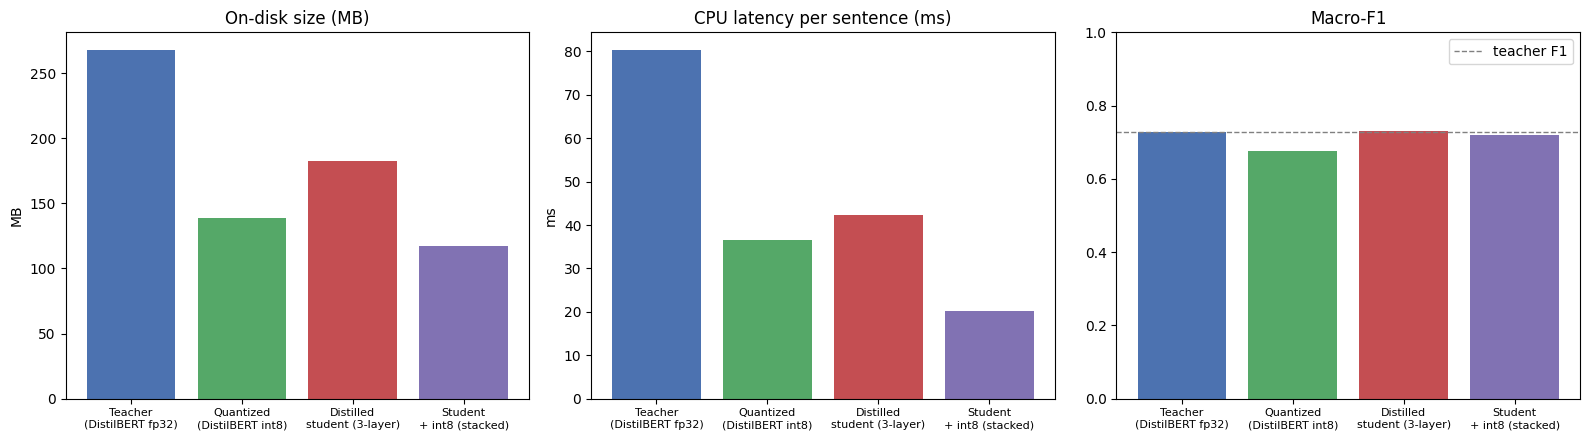

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
names = []
sizes = []
lats = []
f1s = []
for k in order:
    names.append(results[k]["name"].replace(" ", chr(10), 1))
    sizes.append(results[k]["size_mb"])
    lats.append(results[k]["latency_ms"])
    f1s.append(results[k]["macro_f1"])
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]

axes[0].bar(names, sizes, color=colors)
axes[0].set_title("On-disk size (MB)"); axes[0].set_ylabel("MB")

axes[1].bar(names, lats, color=colors)
axes[1].set_title("CPU latency per sentence (ms)"); axes[1].set_ylabel("ms")

axes[2].bar(names, f1s, color=colors)
axes[2].axhline(results["teacher"]["macro_f1"], ls="--", c="gray", lw=1, label="teacher F1")
axes[2].set_title("Macro-F1"); axes[2].set_ylim(0, 1); axes[2].legend()

for ax in axes:
    ax.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

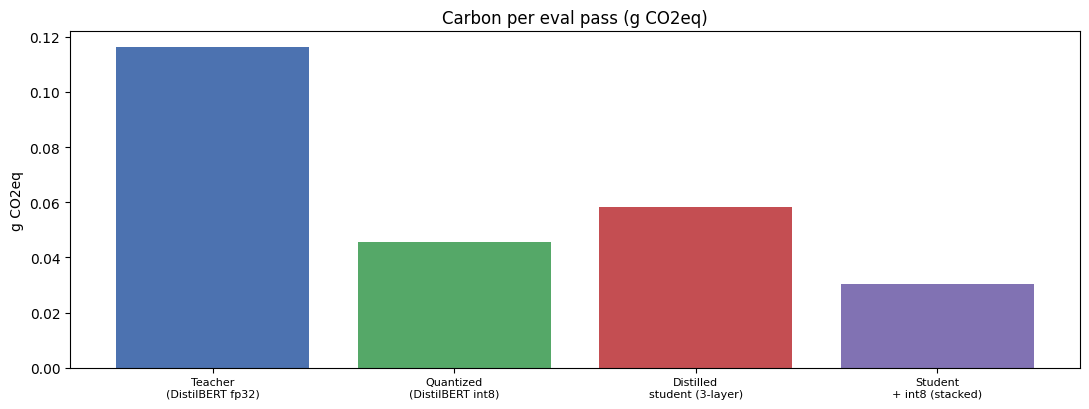

In [24]:
fig, axes = plt.subplots(1, 1, figsize=(11, 4.2))
names = []
ram = []
carbon = []
for k in order:
    names.append(results[k]["name"].replace(" ", chr(10), 1))
    ram.append(results[k].get("ram_peak_mb", float("nan")))
    carbon.append(results[k].get("carbon_kg", float("nan")) * 1e3)
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B3"]
axes.bar(names, carbon, color=colors)
axes.set_title("Carbon per eval pass (g CO2eq)"); axes.set_ylabel("g CO2eq")
axes.tick_params(axis="x", labelsize=8)
plt.tight_layout(); plt.show()

Reading the table and plots together, five conclusions stand out:

1. **Distillation is the cheapest way to preserve accuracy here.** The 3-layer student holds macro F1 at the teacher's level (0.729 to 0.732) while running ~1.9x faster on CPU, the only technique that compresses at no macro-F1 cost. Dynamic quantization needs no retraining and is ~2.2x faster, but on this run it costs about five macro-F1 points (0.729 to 0.677), so it is no longer a free accuracy-preserving win.
2. **The embedding table is the binding constraint on size.** Because dynamic quantization compresses only the Linear layers, both the quantized teacher and the quantized student bottom out around the size of the fp32 embedding matrix (~95 MB). This is why no variant reaches the naive 4x, and it points squarely at embedding compression as the next lever.
3. **Distillation is what actually shrinks the network.** Only the student reduces the parameter count and depth, and on this run that costs essentially no macro F1 (0.729 to 0.732). The visible accuracy loss instead comes from int8 rounding, which is what pulls down the quantized teacher and, more mildly, the stacked student.
4. **Stacking compounds the wins.** The quantized student is the smallest and fastest model by a wide margin (~4.0x faster than the teacher on CPU), making it the natural choice when a hard latency or memory budget dominates and a few points of macro F1 are acceptable.
5. **Energy consistent with speed.** Carbon per evaluation pass tracks runtime, so it follows the throughput ordering rather than the parameter count. The teacher is the slowest and most carbon-intensive (0.116 g CO2eq over the 734-sentence pass), dynamic quantization alone cuts that roughly 2.5x (0.046 g), and the stacked student roughly 4x (0.030 g). A small caveat, the 3-layer student on its own (0.058 g) emits more than the quantized teacher despite having a third fewer parameters, simply because it is the slower of the two on CPU.

In short, the right model is dictated by the deployment constraint. Distillation is the variant that preserves accuracy, so the 3-layer student is the safe default; stacking int8 on top of it gives the smallest, fastest model when a strict size or latency budget binds and a couple of macro-F1 points are acceptable. Dynamic quantization on its own remains the zero-retraining option, but carries the largest accuracy cost here.

### c) Analysis of the student's deficiencies, and improvements
A distilled student is only useful if we understand where and why it diverges from the teacher. We explore compare confusion matrices, inspect the specific sentences on which it diverges from the teacher, and checking its confidence calibration.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
for ax, preds, title in [(axes[0], teacher_preds, "Teacher"), (axes[1], student_preds, "Student")]:
    cm = confusion_matrix(test_labels, preds)
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["Non-Sarc", "Sarc"]); ax.set_yticklabels(["Non-Sarc", "Sarc"])
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center", color="white" if v > cm.max()/2 else "black", fontsize=12)
plt.tight_layout(); plt.show()

print("Per-class F1 (teacher -> student):")
print(f"  Non-Sarcastic: {results['teacher']['f1_nonsarc']:.3f} -> {results['student']['f1_nonsarc']:.3f}")
print(f"  Sarcastic:     {results['teacher']['f1_sarc']:.3f} -> {results['student']['f1_sarc']:.3f}")

In [ ]:
disagree = np.where(student_preds != teacher_preds)[0]
print(f"Student disagrees with teacher on {len(disagree)}/{len(test_labels)} test sentences ({100*len(disagree)/len(test_labels):.1f}%).\n")
inv = {0: "Non-Sarc", 1: "Sarc"}
for i in disagree[:8]:
    print(f"[true={inv[test_labels[i]]}] teacher={inv[teacher_preds[i]]} student={inv[student_preds[i]]}  p_student={student_probs[i].max():.2f}")
    print("   ", test_texts[i][:160].replace(chr(10), ' '), "\n")

In [ ]:
def mean_conf(probs):
    return float(np.max(probs, axis=1).mean())
print("Mean max-probability (confidence):")
print(f"  Teacher: {mean_conf(teacher_probs):.3f}")
print(f"  Student: {mean_conf(student_probs):.3f}")

conf = teacher_probs.max(1)
med = np.median(conf)
easy, hard = conf >= med, conf < med
for mask, lab in [(easy, "easy (teacher-confident) half"), (hard, "hard half")]:
    print(f"  Student accuracy on {lab}: {accuracy_score(test_labels[mask], student_preds[mask]):.3f}")

#### Why the student underperforms?

1. **Capacity bottleneck.** Halving the transformer depth removes layers that sarcasm specifically relies on. As mentioned earlier, the sarcastic signal is a long-range contrast between a literal surface and an implied opposite meaning, exactly the kind of relation that deeper self-attention composes across a sentence. With three layers the student has less room to build that composition, so its largest F1 drop is expected on the "Sarcastic" class and on longer sentences.
2. **Minority-class fragility.** With less capacity the student leans harder on the majority prior (Sarcastic is 63% of the data), which lowers recall on the minority "Non-Sarcastic" class, hence we evaluate on macro F1 rather than accuracy.
3. **Inherited blind spots.** Distillation maximises fidelity to the teacher, so any systematic teacher error is copied and then compounded by the student's lower capacity. Our teacher already trails the fine-tuned RoBERTa state of the art (F1 ~ 0.80) and only modestly exceeds the no-context human ceiling, so the student inherits a boundary that is itself imperfect, and it can never exceed the teacher on what the teacher gets wrong.
4. **The distillation signal is shallow.** We match only final-layer logits. The student receives no guidance about the teacher's internal computation, its attention patterns and hidden states, so it must rediscover those representations from scratch with fewer layers.
5. **The transfer set is small.** Distillation rewards large volumes of (even unlabelled) transfer data, but our student only sees the ~2.9k training sentences, which limits how thoroughly it can sample the teacher's decision function.

#### Improvements and further research directions

If we had more time, these are the things we'd try next. They're listed roughly in order of most to least helpful.

1. **Intermediate-layer distillation.** This is the change we think would make the biggest difference. Right now the student only learns from the teacher's final output (the probabilities it predicts). But the teacher also builds up useful patterns in its middle layers, and the student gets no help with those. The idea is to add extra training targets so the student also tries to match the teacher's hidden layers and attention. That directly fixes deficiency #4, and it should help the student pick up the long-distance "says one thing, means the opposite" pattern that sarcasm relies on.

2. **Make a bigger training set using the teacher's own labels.** The student only saw about 2,900 sentences, which is pretty small (deficiency #5). The handy thing about distillation is that we don't need human-labelled data, we just need the teacher's guesses. So we can generate a big batch of extra sentences using the same augmentation tricks from Parts 2 and 3, have the teacher label them, and train the student on the larger set. In Part 2, fake labels from an LLM actually hurt the small model because they were often wrong. That won't happen here, since the teacher is doing the labelling, so the extra data just gives the student more examples of how the teacher decides. There's a ready-to-run example in the optional cell below.

3. **Use a stronger teacher.** A student trained this way can only get about as good as its teacher, and it copies the teacher's mistakes along the way (deficiency #3). Our teacher isn't the best model available; it falls short of the top RoBERTa scores. If we distilled from a stronger teacher instead, like a fine-tuned RoBERTa-large or several models combined, we'd raise the target the student is aiming at. This is really the only way for our small model to get past the blind spots it currently inherits from the teacher.

#### Conclusion

Our practical conclusion is that the choice of compressed model should follow the deployment constraint rather than a single "best" verdict: quantize when accuracy must be preserved and CPU cost reduced, and distil, optionally then quantize, when a strict size or latency budget binds.